In [52]:
# Objective: 
#  Identify customers who are likely to leave the bank. 

# Dataset: 
#  Churn Modelling Dataset 
# Instructions: 

#  Clean and prepare the dataset. 
#  Encode categorical features such as geography and gender. 
#  Train a classification model. 
#  Analyze feature importance to understand what influences churn.

# importing libraries such as pandas, matplotlib, seaborn, and scikit-learn with Label Encoder, Train Test Split, Random Forest Classifier, accuracy_score, and confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
# loading the chrun modeling dataset using read_csv function and storing in df variable
df = pd.read_csv('churn_modeling_dataset.csv')

In [ ]:
# observing starting 5 rows of the dataset using head function
df.head()

In [11]:
# observing all variables/columns
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [ ]:
# checking for null values in the dataset 
df.isnull().sum()

In [ ]:
# dropping unnecessary variables
df = df.drop(['CustomerId', 'RowNumber', 'Surname'], axis=1)

In [20]:
# correcting the Excited spelling by using rename function
df.rename(columns = {'Exited' : 'Excited'}, inplace=True)

In [16]:
# observing if the geography contain more than 2 categories, then we will use one-hot encoding
df['Geography'].unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

In [19]:
# Applying Label Encoder on Gender (because it has only two values), and one-hot encoder to Geography to create dummy variables
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

<Axes: xlabel='Excited', ylabel='count'>

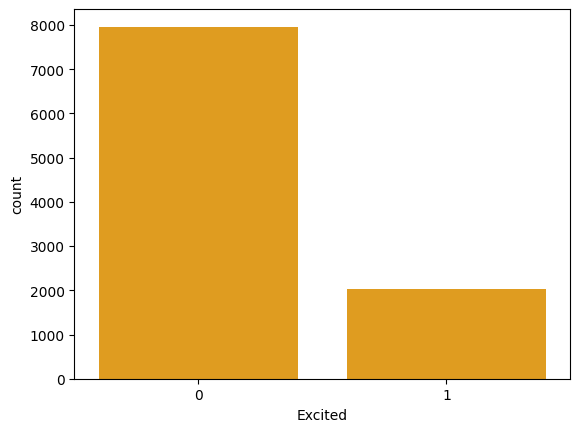

In [38]:
# visualizing the Excited variable using countplot to observe the frequency
sns.countplot(x='Excited', color='orange', data = df)

Text(0, 0.5, 'Frequency')

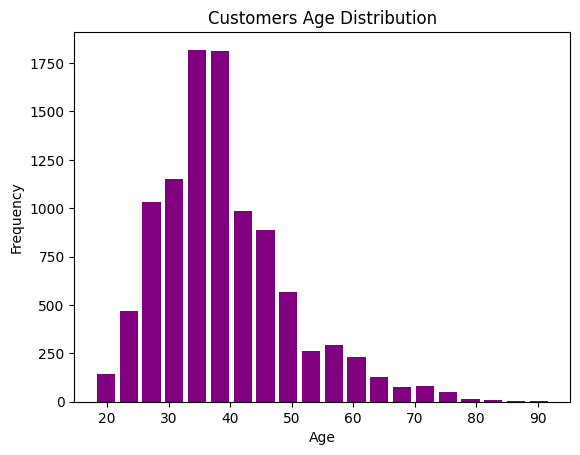

In [39]:
# # visualizing the Customers age variable using histogramt to observe their age distribution
plt.hist(df['Age'], rwidth=0.8, color='purple', bins = 20)
plt.title('Customers Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

<Axes: xlabel='Gender', ylabel='count'>

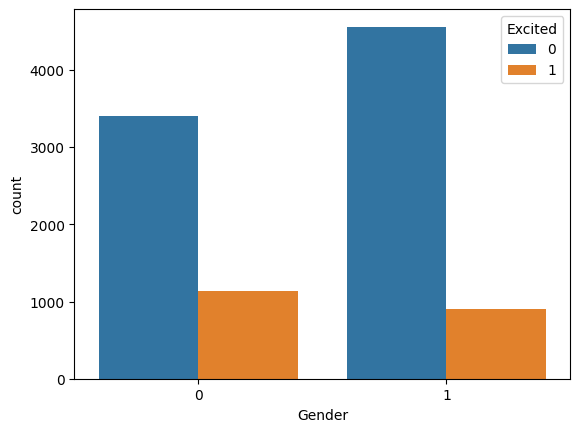

In [42]:
# visualizing the Gender vs Excited variables using countplot to observe their excited state on the basis of gender
sns.countplot(x='Gender', hue='Excited', data = df)

In [43]:
print(le.classes_)

['Female' 'Male']


In [44]:
# defining feature(X) and traget(y) variables
X = df.drop('Excited', axis=1)
y = df['Excited']

In [47]:
# splitting the variales into train/testing using train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

In [50]:
# loading and fitting Random Forest Classifier on the X and y train data  
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [57]:
# predicting Excited(y) variables by using predict function 
y_pred = model.predict(X_test)
print(y_pred)

[0 0 0 ... 0 0 0]


In [55]:
# checking the accuracy score of this model
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.859125


In [54]:
# applying confusion matrix to observe the combinations of results
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:' , cm)

Confusion Matrix: [[6149  224]
 [ 903  724]]


Text(50.722222222222214, 0.5, 'Actual')

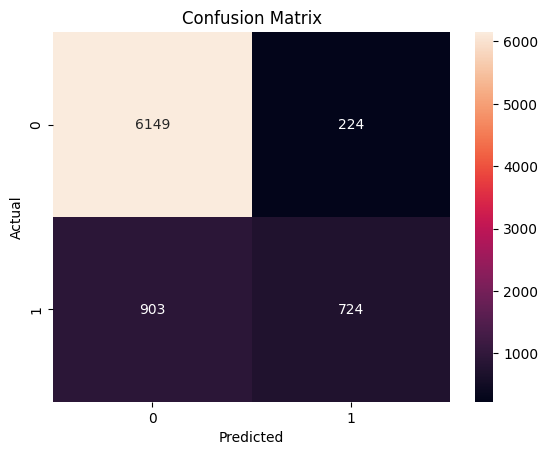

In [59]:
# visualizing the confusion matrix so that we can easily understand it
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [65]:
# Evaluating how much each feature(I.V) contributes in predicting the y(Excited) variable using feature importance function

importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature" : X.columns,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(          # sorting them to get result in high-low order
    by = "Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance_df)

Feature Importance:
              Feature  Importance
2                 Age    0.234686
0         CreditScore    0.150612
8     EstimatedSalary    0.141001
4             Balance    0.135972
5       NumOfProducts    0.114276
3              Tenure    0.083572
7      IsActiveMember    0.045153
9   Geography_Germany    0.030562
1              Gender    0.025707
6           HasCrCard    0.022442
10    Geography_Spain    0.016017
